<a href="https://colab.research.google.com/github/JorgeMoragaCalvo/data-science-playground/blob/main/numpy_comway.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1: Generalización del automáta de Conway
- Instrucciones de uso:
  - Para la mayor parte del programa se debe descomentar la parte de la importación de `Numpy` y comentar la parte de `CuPy`. Con `Numpy` se buscaron patrones y se graficaron las diferencias entre una implementación vectorizado y otra que utiliza `Python` puro.
  - Para utilizar `CuPy` se debe comentar la parte de la importación`Numpy` y utilizar una funcion `update_toroid_vectorized_cupy()`.


## INTRODUCCION
El código del presente trabajo aborda la simulación de un sistema dinámico que evoluciona sobre una cuadrícula o grilla multidimensional. Este tipo de sistemas, los autómatas celulares, son matemáticamente fáciles de describir, pero con el potencial de exhibir un comportamiento complejo a lo largo del tiempo. Formalmente fueron introducidos por Ulam y von Neumann en la década de 1950; los autómatas celulares son comunes en diversas áreas científicas, como la física, la biología o las ciencias sociales, para modelar fenómenos como la difusión, el crecimiento de poblaciones, la propagación de opiniones o la teoría del lenguaje formal. Este tipo de  simulaciones se caracterizan por desarrollarse en un espacio con fronteras toroidales, lo que significa que los bordes de la cuadrícula se conectan entre sí, eliminando efectos de borde. El objetivo del presente trabajo es comparar estrategias de implementación distintas para realizar la actualización de las celdas dadas en el enunciado: una basada en operaciones vectorizadas, aprovechando las capacidades de librerías numéricas como `NumPy` y `SciPy`, otra basada en el uso de ciclos explícitos en `Python` puro y finalmente una implementación en `CuPy`. Esta comparación busca ilustrar las diferencias en eficiencia y rendimiento entre los distintos enfoques. Además, dadas las reglas de actualización particulares de las celdas, se intenta encontrar combinaciones de parámetros que den como resultado algún patrón periódico o semiperiódico.

Implicaciones y desafíos:
- Implementación técnica:
  - Usar `CuPy` implica trabajar con arreglos multidimensionales similares a `NumPy`, pero en GPU.
  - El cálculo de las vecindades requiere una convolución o un método equivalente para sumar los estados de las celdas vecinas, considerando los bordes periódicos.
  - Dividir Sm en tres intervalos equiespaciados implica definir umbrales basados en el número de vecinos y aplicar reglas condicionales de forma vectorizada.
- Patrones semi-periódicos:
  - Encontrar configuraciones iniciales que generen patrones semi-periódicos puede requerir experimentación numérica, ya que el comportamiento depende de `d`, `m`, `r` y el tamaño de la grilla.
  - Podría implicar simular varias configuraciones iniciales aleatorias o estructuradas y analizar la evolución para detectar periodicidad.
- Optimización:
  - Evitar ciclos requiere diseñar cuidadosamente las operaciones de actualización usando funciones de alto nivel como reducciones, máscaras booleanas y operaciones de convolución.

## DESARROLLO
La simulación comienza con la creación de una grilla inicial, que puede ser una matriz de ceros o llenarse con valores enteros aleatorios dentro de un rango específico. Las dimensiones de esta grilla son configurables. Paralelamente, se define el concepto de "vecindad" mediante la creación de un `kernel`. Este `kernel` es una pequeña matriz auxiliar que especifica qué celdas circundantes a una celda dada se consideran sus vecinas, típicamente basándose en un radio de distancia euclidiana desde el centro; la propia celda central se excluye de su vecindad.

Una vez configurados la grilla y el `kernel`, la simulación avanza en pasos de tiempo discretos. En cada paso, el primer cálculo crucial es determinar, para cada celda de la grilla, la suma de los valores actuales de todas sus celdas vecinas según lo define el `kernel`. Ambas implementaciones (vectorizada y por ciclos) realizan este cálculo de manera eficiente utilizando la función de convolución de `Scipy`, configurada para manejar las condiciones de contorno toroidales (modo _wrap_). Esto asegura que el cálculo de la suma de vecinos sea rápido y consistente en ambos métodos.

In [ ]:
# Configuración para Google Colab
%matplotlib inline
#import numpy as np
import cupy as np
from scipy.ndimage import convolve
import matplotlib.pyplot as plt

### Parámetros del modelo


- `n`: Tamaño de la grilla.
- `d`: Número de dimensiones.
- `m`: Número de estados posibles.
- `r`: Radio de interacción entre celdas.
- `t`: Número de pasos de simulación.

### Construcción del modelo

#### 1. Inicialización de la grilla
La función `create_grid()` crea una grilla multi-dimensional para autómata cellular. Sus argumentos son los siguientes:
- n (int): El tamaño de la rejilla a lo largo de cada dimensión. La grilla será hipercúbica con lado n.
- d (int): El número de dimensiones de la grilla.
- m (int): El número de estados posibles para cada celda (exclusivo). Las celdas tendrán estados enteros de 0 a $m$.
- aleatorio (bool, opcional): Si es True, inicializa la grilla con valores enteros aleatorios entre 0 y $m$. Si es False (valor por defecto), inicializa la grilla con ceros.

Retorna un array `NumPy` que representa la grilla inicializada. Tendrá `d` dimensiones, cada una de tamaño `n`. El tipo de dato será entero `int`.

Para definir la forma de la grilla se utiliza `shape = (n, ) * d`, donde `(n, )` crea una tupla de un solo elemento (n). Luego se multiplica por `d`, lo cual hace que la tupla se repita `d` veces. Es decir:
- Si $n=10$, $d=2$ $→$ shape = (10,) * 2 $→$ (10, 10)
- Si $n=5$, $d=3$ $→$ shape = (5,) * 3 $→$ (5, 5, 5)

Por lo tanto, `shape` es una tupla que describe las dimensiones del array (NumPy) que se va a crear.

In [ ]:
%%time
def create_grid(n, d, m, aleatorio=False):
    shape = (n,) * d
    if aleatorio:
        return np.random.randint(0, m, size=shape, dtype=int)
    return np.zeros(shape, dtype=int)

---
#### 2. Definición del vecindario
En el contexto de SciPy `convolve`, el kernel es un array pequeno que representa un operador matemático o filtro. Define cómo cada punto en el array de entrada interactúa con sus vecinos durante el proceso de convolucion.

La función `create_kernel()`, crea un kernel (un núcleo) para definir la vecindad en el autómata celular multi-dimensional, basado en las reglas de actualización del problema (distancia Euclidiana). El kernel es una máscara que se usará (junto con la convolución) para sumar los estados de las celdas vecinas. Sus argumentos son:

- `r` (int): El radio de la vecindad. Las celdas dentro de esta distancia Euclidiana desde el centro (excluyendo el centro) se considerarán vecinas. Se usó un estándar de r=1.
- `d` (int): El número de dimensiones del espacio/rejilla donde operará el kernel.

La funcion retorna un array NumPy de `d` dimensiones que representa el kernel/máscara de vecindad. Contiene 1s para las celdas vecinas y 0s para las no-vecinas y la celda central. Su forma será (2r+1) x ... x (2r+1). Para 2D, el kernel será:
```python
[[0 1 0]
 [1 0 1]
 [0 1 0]]
```


In [ ]:
%%time
def create_kernel(r, d):
    # Forma del núcleo: (2r+1, 2r+1, ..., 2r+1) en d dimensiones
    kernel_shape = (2 * r + 1,) * d
    # Generar coordenadas de todas las celdas en el núcleo
    coords = np.indices(kernel_shape, dtype=float)
    # Calcular los offsets respecto al centro (r, r, ..., r)
    offsets = coords - r
    # Calcular la distancia euclidiana: sqrt(sum((x_i - r)^2)
    distances = np.sqrt(np.sum(offsets**2, axis=0))
    # Crear el núcleo: 1 si la distancia es <= r, 0 si no
    kernel = (distances <= r + 1e-10).astype(int)
    # Excluir la celda central
    kernel[tuple([r] * d)] = 0
    return kernel

#### 3. Dinámica del sistema
El uso de la convolución en el presente trabajo se justifica ya que, se trata de una operación matemática que combina dos funciones o señales o, en este caso específico, dos arreglos para producir un tercero. Por lo tanto, desde una perspectiva matemática, como por su adecuación al problema de sumar vecinos en una grilla, es ideal para el problema a tratar.

Matemáticamente, la convolución discreta 2D (o N-D) entre una grilla y un `kernel` (el `kernel` de vecindad) se define como una suma ponderada de los vecinos de cada celda (en este caso). En este problema específico, el `kernel` se construye de tal manera que tiene valor `1` en las posiciones correspondientes a los vecinos (relativos al centro) y `0` en el resto (incluido el centro). Cuando se realiza la convolución $convolve(grid, kernel)$, la operación matemática en cada celda $(i, j)$ se reduce a: $Suma( grid[vecino] \cdot 1 ) + Suma( grid[no\_vecino] \cdot 0 )$.

En cuanto al contexto del problema, cuya simulación requiere calcular la suma de los vecinos para _cada_ celda de la grilla en cada paso de tiempo, la forma manual de realizarlo sería escribir bucles anidados: un ciclo externo para cada celda de la grilla, y ciclos internos para iterar sobre los desplazamientos relativos de los vecinos, calcular las coordenadas absolutas del vecino (manejando el _wrap_ del toroide manualmente), y acumular la suma. Todo lo anterior puede ser propenso a errores, muy complejo de escribir (especialmente en N dimensiones) y computacionalmente muy lento en `Python` puro. Por este motivo, se justifica el uso de la función `convolve` de `scipy.ndimage` ya que está altamente optimizada. Realiza la operación de "deslizar" el kernel sobre la grilla y sumar de manera mucho más eficiente que los ciclos explícitos en `Python`.

Además, el argumento _mode='wrap'_ de la función _convolve_ trata los bordes de la grilla como si estuvieran conectados (toroidalmente). Esto maneja automáticamente las condiciones de contorno del problema sin necesidad de lógica adicional _if/else_ en el código.

Tras obtener la suma de vecinos para cada celda, se aplican las reglas de actualización. Estas reglas dependen de comparar dicha suma con dos umbrales predefinidos, los cuales se calculan en función del número de vecinos y un parámetro de escala. Generalmente, si la suma es baja (inferior al primer umbral), el valor de la celda disminuye; si está en un rango intermedio, aumenta; y si es alta (superior al segundo umbral), disminuye nuevamente. Se implementa una salvaguarda para que los valores de las celdas no puedan ser negativos (su valor mínimo es cero).

Aquí es donde radica la diferencia fundamental entre las dos funciones presentadas. La versión vectorizada utiliza el poder de `Numpy`: crea máscaras booleanas (arreglos de Verdadero/Falso) que identifican todas las celdas que cumplen cada una de las condiciones de actualización simultáneamente. Luego, aplica las operaciones aritméticas (suma o resta) directamente a las secciones de la cuadrícula seleccionadas por estas máscaras. Todo esto ocurre a un nivel bajo, optimizado en `C` o `Fortran`, sin bucles explícitos en `Python` para aplicar las reglas.

Por el contrario, la versión basada en ciclos recorre explícitamente cada una de las celdas de la cuadrícula utilizando un bucle _for_. Dentro del bucle, para la celda actual, recupera su suma de vecinos (precalculada por la convolución) y su valor actual. Luego, ejecuta una serie de condicionales (_if/elif/else_) para determinar cómo actualizar el valor de esa celda específica en una nueva cuadrícula. Este proceso se repite individualmente para todas las celdas.

Ambos métodos siguen exactamente la misma lógica matemática y reglas de simulación, pero difieren radicalmente en la estrategia de implementación para aplicar dichas reglas después de calcular la suma de vecinos.

<!-- Formalmente, para funciones discretas, la convolución de secuencias $f$ y $g$ se define como: \\
\begin{equation}
  (f * g)[n] = \sum_{m = -∞}^{∞} f[m] ⋅ g[n - m]
\end{equation}

Cuando se trabaja con grillas toroidales, como en el problema, se utiliza la convolución circular donde las senales se tratan como periódicas. Una malla toroidal es una estructura con condiciones de contorno periódicas, donde los bordes se envuelven. En este contexto, la convolución se convierte en circular y se define como: \\

\begin{equation}
  (f \circledast g)\space [n]\sum_{m=0}^{N-1} f[m] \cdot g[(n - m) \mod N]
\end{equation} -->


##### Funcion vectorizada
Simula 't' pasos de un autómata celular generalizado N-dimensional en una rejilla toroidal (con bordes periódicos) usando vectorización.

    Args:
        grid (numpy.ndarray): El estado inicial de la rejilla del autómata.
                              Debe ser un array NumPy N-dimensional.
        r (int): El radio de la vecindad (usado para crear el kernel).
        m (int): El número de estados posibles (enteros).
        t (int): El número de pasos de tiempo (generaciones) a simular.

    Returns:
        numpy.ndarray: El estado de la rejilla después de 't' pasos de simulación.


In [ ]:
%%time
def update_toroid_vectorized(grid, r, m, t):
    # --- Inicialización ---
    current_grid = grid.copy().astype(int)
    # Detecta el número de dimensiones desde la rejilla
    n = len(grid.shape)
    kernel = create_kernel(r, n) # kernel de vecindad (radio r, dimensión n)

    # --- Cálculo de Parámetros para las Reglas ---
    num_neighbors = np.sum(kernel)

    # Sm: Factor de escala basado en el número de estados y vecinos.
    Sm = m * num_neighbors

    # Rangos que dividen el rango posible de 'sum_neighbors' en tres zonas.
    interval_1 = Sm / 3
    interval_2 = 2 * Sm / 3

    #print(f"Cuadrícula en t=0:")
    #print(grid)
    #print()

    # --- Ciclo de Simulación ---
    for step in range(1, t + 1):
        # 1. Cálculo de la suma de los estados de los vecinos para TODAS las celdas
        # usando convolución con el kernel.
        sum_neighbors = convolve(current_grid, kernel, mode='wrap')
        # - `current_grid`: Estado actual del autómata.
        # - `kernel`: Máscara que define qué celdas son vecinas (y les da peso 1).
        # - `mode='wrap'`: Implementa las condiciones de borde TOROIDALES.
        #       Los bordes se conectan.
        # - `sum_neighbors`: Array del mismo tamaño que 'grid', donde cada
        #                       celda contiene la suma de los estados (0 a m + 1)
        #                       de sus vecinos en 'current_grid'.

        # 2. Preparar la nueva rejilla (actualización simultánea)
        new_grid = current_grid.copy()
        # Es crucial para que todas las celdas se actualicen
        # basándose en el estado del paso *anterior* ('current_grid').

        # 3. Aplicar las Reglas de Actualización usando Máscaras Booleanas (Vectorización)
        # Regla 1: Suma de vecinos BAJA -> Decrementar estado
        mask_decrease_1 = (sum_neighbors < interval_1)
        new_grid[mask_decrease_1] = current_grid[mask_decrease_1] - 1
        new_grid[mask_decrease_1 & (current_grid == 0)] = 0

        # Regla 2: Suma de vecinos MEDIA -> Incrementar estado
        mask_increase = (sum_neighbors >= interval_1) & (sum_neighbors < interval_2)
        new_grid[mask_increase] = current_grid[mask_increase] + 1
        mask_decrease_2 = (sum_neighbors >= interval_2)

        # Regla 3: Suma de vecinos ALTA -> Decrementar estado
        new_grid[mask_decrease_2] = current_grid[mask_decrease_2] - 1
        new_grid[mask_decrease_2 & (current_grid == 0)] = 0

        # 4. Actualizar la rejilla para el siguiente paso
        current_grid = new_grid

        #print(f"Cuadrícula en t={step}:")
        #print(current_grid)
        #print()
    return new_grid

##### Funcion con ciclos
Simula 't' pasos de un autómata celular generalizado N-dimensional en una rejilla toroidal, utilizando ciclos explícitos (bucles for) para la aplicación de reglas (y la creación del kernel), con el objetivo de compararla con una versión vectorizada.

    Args:
        grid (numpy.ndarray): Estado inicial de la rejilla.
        r (int): Radio de la vecindad.
        m (int): Número de estados posibles.
        t (int): Número de pasos de tiempo a simular.

    Returns:
        numpy.ndarray: El estado de la rejilla después de 't' pasos.


In [ ]:
%%time
def update_toroid_cycles(grid, r, m, t):
    current_grid = grid.copy().astype(int)
    n = len(current_grid.shape)
    kernel_shape = (2 * r + 1,) * n # kernel de vecindad (radio r, dimensión n)

    # --- Creación del Kernel (Método No Vectorizado) ---
    # se recrea el kernel usando un ciclo explícito.
    kernel = np.zeros(kernel_shape)
    center = tuple([r] * n)

    # Ciclo sobre cada índice (posición) en la forma del kernel
    for idx in np.ndindex(kernel_shape):
        # Calcula el desplazamiento desde el centro para esta posición idx
        offsets = [i - r for i in idx]
        # Calcula la distancia Euclidiana para esta posición
        if np.sqrt(sum(o**2 for o in offsets)) <= r:
            kernel[idx] = 1

    kernel[center] = 0 # Excluye el centro como vecino (misma regla)

    # --- Cálculo de Parámetros para las Reglas ---
    num_neighbors = np.sum(kernel)
    #print(f"Número de vecinos: {num_neighbors}")
    Sm = m * num_neighbors
    interval_1 = Sm / 3
    interval_2 = 2 * Sm / 3

    #print(f"Cuadrícula en t=0:")
    #print(grid)
    #print()

    # --- Ciclo de Simulación ---
    for step in range(t):
        sum_neighbors = convolve(current_grid, kernel, mode='wrap')
        new_grid = current_grid.copy()

        # 3. Aplicar Reglas de Actualización (Método No Vectorizado con ciclos)
        for idx in np.ndindex(current_grid.shape):
            Sk = sum_neighbors[idx]
            current_value = current_grid[idx]
            if Sk < interval_1:
                new_grid[idx] = current_value - 1 if current_value > 0 else 0
            elif Sk < interval_2:
                new_grid[idx] = current_value + 1
            else:
                new_grid[idx] = current_value - 1 if current_value > 0 else 0

        # 4. Actualizar la rejilla para el siguiente paso
        current_grid = new_grid
        #print(f"Cuadrícula en t={step + 1}:")
        #print(current_grid)
        #print()

    return current_grid

### Experimentación
Como el objetivo es comparar tiempo de ejecución entre dos implementaciones (vectorizada vs ciclos), se decidió dejar fijo el parámetro t en $t = 20$ (que representa el numero de iteraciones). De ese modo, se aísla el efecto del algoritmo, es decir, no se está comparando también el impacto de cuántas veces se itera y facilita la comparación entre diferentes configuraciones de `n`, `d`, `m`, `r`.

#### Experimento 1
Grilla 1. Parámetros:
- `n=15`
- `d=3`
- `m=3`
- `r=1`
- total de celdas = **3375**

In [ ]:
grid01 = create_grid(n=15, d=3, m=3, aleatorio=True)

In [ ]:
%%time
result_cycles_grid01 = update_toroid_cycles(grid01, r=1, m=3, t=20)

CPU times: user 74.2 ms, sys: 0 ns, total: 74.2 ms
Wall time: 74.1 ms


In [ ]:
%%time
result_vect_grid01 = update_toroid_vectorized(grid01, r=1, m=3, t=20)

CPU times: user 9.38 ms, sys: 0 ns, total: 9.38 ms
Wall time: 9.05 ms


---
#### Experimento 2
Grilla 2. Parámetros:
- n = 20
- d = 3
- m = 4
- r = 2
- total celdas = **8000**

In [ ]:
grid02 = create_grid(n=20, d=3, m=4, aleatorio=True)

In [ ]:
%%time
result_cycles_grid02 = update_toroid_cycles(grid02, r=2, m=4, t=20)

CPU times: user 187 ms, sys: 0 ns, total: 187 ms
Wall time: 187 ms


In [ ]:
%%time
result_vect_grid02 = update_toroid_vectorized(grid02, r=2, m=4, t=20)

CPU times: user 19.1 ms, sys: 259 µs, total: 19.4 ms
Wall time: 18.7 ms


---
#### Experimento 3
Grilla 3. Parámetros:
- n = 30
- d = 3
- m = 6
- r = 2
- total de celdas = **27000**

In [ ]:
grid03 = create_grid(n=30, d=3, m=6, aleatorio=True)

In [ ]:
%%time
result_cycles_grid03 = update_toroid_cycles(grid03, r=2, m=6, t=20)

CPU times: user 638 ms, sys: 0 ns, total: 638 ms
Wall time: 638 ms


In [ ]:
%%time
result_vect_grid03 = update_toroid_vectorized(grid03, r=2, m=6, t=20)

CPU times: user 57.7 ms, sys: 0 ns, total: 57.7 ms
Wall time: 57.6 ms


---
#### Experimento 4
Grilla 4. Parámetros:
- n = 40
- d = 3
- m = 6
- r = 1
- total de celdas = **64000**

In [ ]:
grid04 = create_grid(n=40, d=3, m=3, aleatorio=True)

In [ ]:
%%time
result_cycles_grid04 = update_toroid_cycles(grid04, r=1, m=3, t=20)

CPU times: user 2.04 s, sys: 611 µs, total: 2.04 s
Wall time: 2.1 s


In [ ]:
%%time
result_vect_grid04 = update_toroid_vectorized(grid04, r=1, m=3, t=20)

CPU times: user 104 ms, sys: 0 ns, total: 104 ms
Wall time: 109 ms


---
#### Experimento 5
Grilla 5. Parámetros:
- n = 17
- d = 4
- m = 6
- r = 1
- total de celdas = **83521**

In [ ]:
grid05 = create_grid(n=17, d=4, m=6, aleatorio=True)

In [ ]:
%%time
result_cycles_grid05 = update_toroid_cycles(grid05, r=1, m=6, t=20)

CPU times: user 2.23 s, sys: 3 ms, total: 2.24 s
Wall time: 2.26 s


In [ ]:
%%time
result_vect_grid05 = update_toroid_vectorized(grid05, r=2, m=6, t=20)

CPU times: user 321 ms, sys: 0 ns, total: 321 ms
Wall time: 319 ms


---
#### Experimento 6
Grilla 6. Parámetros:
- n = 20
- d = 4
- m = 4
- r = 2
- total de celdas = **160000**

In [ ]:
grid06 = create_grid(n=20, d=4, m=4, aleatorio=True)

In [ ]:
%%time
result_cycles_grid06 = update_toroid_cycles(grid06, r=2, m=4, t=20)

CPU times: user 4.37 s, sys: 7.16 ms, total: 4.37 s
Wall time: 4.39 s


In [ ]:
%%time
result_vect_grid06 = update_toroid_vectorized(grid06, r=2, m=4, t=20)

CPU times: user 572 ms, sys: 0 ns, total: 572 ms
Wall time: 571 ms


---
#### Experimento 7
Grilla 7. Parámetros:
- n = 25
- d = 4
- m = 6
- r = 2
- total de celdas = **390625**

In [ ]:
grid07 = create_grid(n=25, d=4, m=6, aleatorio=True)

In [ ]:
%%time
result_cycles_grid07 = update_toroid_cycles(grid07, r=2, m=3, t=20)

CPU times: user 11.7 s, sys: 19 ms, total: 11.7 s
Wall time: 11.8 s


In [ ]:
%%time
result_vect_grid07 = update_toroid_vectorized(grid07, r=2, m=3, t=20)

CPU times: user 1.35 s, sys: 8.95 ms, total: 1.36 s
Wall time: 1.36 s


---
#### Experimento 8
Grilla 3. Parámetros:
- n = 15
- d = 5
- m = 6
- r = 1
- total de celdas = **759375**

In [ ]:
grid08 = create_grid(n=15, d=5, m=6, aleatorio=True)

In [ ]:
%%time
result_cycles_grid08 = update_toroid_cycles(grid08, r=1, m=6, t=20)

CPU times: user 21.2 s, sys: 40.4 ms, total: 21.2 s
Wall time: 21.4 s


In [ ]:
%%time
result_vect_grid08 = update_toroid_vectorized(grid08, r=1, m=6, t=20)

CPU times: user 1.18 s, sys: 12.4 ms, total: 1.19 s
Wall time: 1.19 s


---
#### Experimento 9
Grilla 3. Parámetros:
- n = 18
- d = 5
- m = 3
- r = 2
- total de celdas = **1889568**

In [ ]:
grid09 = create_grid(n=18, d=5, m=3, aleatorio=True)

In [ ]:
%%time
result_cycles_grid09 = update_toroid_cycles(grid09, r=2, m=3, t=20)

CPU times: user 1min 7s, sys: 145 ms, total: 1min 7s
Wall time: 1min 8s


In [ ]:
%%time
result_vect_grid09 = update_toroid_vectorized(grid09, r=2, m=3, t=20)

CPU times: user 17.7 s, sys: 55.5 ms, total: 17.8 s
Wall time: 17.9 s


---
#### Experimento 10
Grilla 3. Parámetros:
- n = 20
- d = 5
- m = 6
- r = 1
- total de celdas = **3200000**

In [ ]:
grid10 = create_grid(n=20, d=5, m=6, aleatorio=True)

In [ ]:
%%time
result_cycles_grid10 = update_toroid_cycles(grid10, r=1, m=6, t=20)

CPU times: user 1min 26s, sys: 270 ms, total: 1min 26s
Wall time: 1min 28s


In [ ]:
%%time
result_vect_grid10 = update_toroid_vectorized(grid10, r=1, m=6, t=20)

CPU times: user 5.36 s, sys: 22.6 ms, total: 5.38 s
Wall time: 5.39 s


---
### Recopilación Resultados Experimentos


Resultados de la experimentación (tiempos en milisegundos):
   d  m  r   n  time_non_vectorized  time_vectorized  cantidad celdas
0  3  3  1  15                 74.1             9.05             3375
1  3  4  2  20                187.0            18.70             8000
2  3  6  2  30                638.0            57.60            27000
3  3  3  1  40               2100.0           109.00            64000
4  4  6  1  17               2260.0           319.00            83521
5  4  4  2  20               4390.0           571.00           160000
6  4  6  2  25              11800.0          1360.00           390625
7  5  6  1  15              21400.0          1190.00           759375
8  5  3  2  18              68000.0         17900.00          1889568
9  5  6  1  20              88000.0          5390.00          3200000


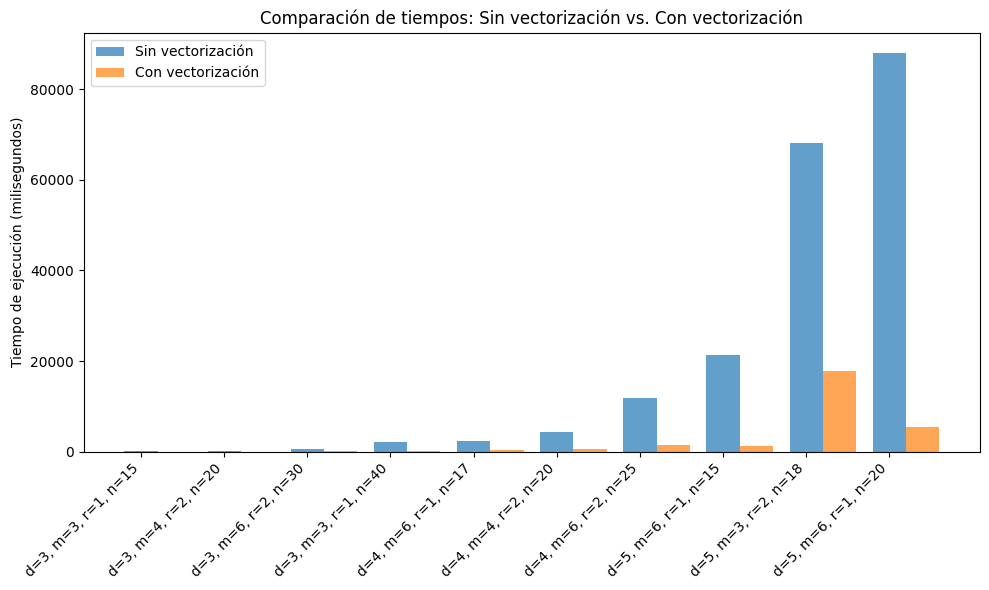

,d,m,r,n,time_non_vectorized,time_vectorized,cantidad celdas
0,3,3,1,15,74.1,9.05,3375
1,3,4,2,20,187.0,18.70,8000
2,3,6,2,30,638.0,57.60,27000
3,3,3,1,40,2100.0,109.00,64000
4,4,6,1,17,2260.0,319.00,83521
5,4,4,2,20,4390.0,571.00,160000
6,4,6,2,25,11800.0,1360.00,390625
7,5,6,1,15,21400.0,1190.00,759375
8,5,3,2,18,68000.0,17900.00,1889568
9,5,6,1,20,88000.0,5390.00,3200000


In [ ]:
import pandas as pd
def plot_results(results):
    df = pd.DataFrame(results)
    print("\nResultados de la experimentación (tiempos en milisegundos):")
    print(df)

    plt.figure(figsize=(10, 6))
    x = range(len(results))
    plt.bar(x, df['time_non_vectorized'], width=0.4, label='Sin vectorización', alpha=0.7)
    plt.bar([i + 0.4 for i in x], df['time_vectorized'], width=0.4, label='Con vectorización', alpha=0.7)
    plt.xticks(x, [f"d={e['d']}, m={e['m']}, r={e['r']}, n={e['n']}" for e in results], rotation=45, ha='right')
    plt.ylabel('Tiempo de ejecución (milisegundos)')
    plt.title('Comparación de tiempos: Sin vectorización vs. Con vectorización')
    plt.legend()
    plt.tight_layout()
    plt.savefig('time_comparison.png')
    plt.show()
    return df

example_results = [
    {'d': 3, 'm': 3, 'r': 1, 'n': 15, 'time_non_vectorized': 74.1, 'time_vectorized': 9.05, 'cantidad celdas': 3375},
    {'d': 3, 'm': 4, 'r': 2, 'n': 20, 'time_non_vectorized': 187, 'time_vectorized': 18.7, 'cantidad celdas': 8000},
    {'d': 3, 'm': 6, 'r': 2, 'n': 30, 'time_non_vectorized': 638, 'time_vectorized': 57.6, 'cantidad celdas': 27000},
    {'d': 3, 'm': 3, 'r': 1, 'n': 40, 'time_non_vectorized': 2100, 'time_vectorized': 109, 'cantidad celdas': 64000},
    {'d': 4, 'm': 6, 'r': 1, 'n': 17, 'time_non_vectorized': 2260, 'time_vectorized': 319, 'cantidad celdas': 83521},
    {'d': 4, 'm': 4, 'r': 2, 'n': 20, 'time_non_vectorized': 4390, 'time_vectorized': 571, 'cantidad celdas': 160000},
    {'d': 4, 'm': 6, 'r': 2, 'n': 25, 'time_non_vectorized': 11800, 'time_vectorized': 1360, 'cantidad celdas': 390625},
    {'d': 5, 'm': 6, 'r': 1, 'n': 15, 'time_non_vectorized': 21400, 'time_vectorized': 1190, 'cantidad celdas': 759375},
    {'d': 5, 'm': 3, 'r': 2, 'n': 18, 'time_non_vectorized': 68000, 'time_vectorized': 17900, 'cantidad celdas': 1889568},
    {'d': 5, 'm': 6, 'r': 1, 'n': 20, 'time_non_vectorized': 88000, 'time_vectorized': 5390, 'cantidad celdas': 3200000},
]

plot_results(example_results)

##### Análisis resultados
Habiendo dejado fijo el parámetro del tiempo (es decir, la cantidad de iteraciones que representa la evolución en el tiempo del autómata). Se ve, principalmente, que el desempeño del algoritmo está afectado por el tamaño de la grilla, el número de dimensiones y por la cantidad de vecinos que se deben calcular en cada iteraciones; para el caso de `d = 5`, el algoritmo debe considerar 70 vecinos en cada operación. Lo anterior, se refleja en los experimentos 9 y 10 ya que, a pesar de el experimento 9 tenía menos celdas que 10, demoró más tiempo debido a la cantidad de vecinos a incluir en el cálculo. El parámetro de los estados en cada celda no afecta mayormente el rendimiento del algoritmo.

### BUSQUEDA PATRONES
Uso de indicadores numéricos para evaluar patrones. Se utilizaron tres indicadores: suma total, varianza y entropía.
Análisis de los Indicadores Propuestos:
- Suma Total (np.sum(grid)):
  - Mide la "masa" o "actividad" total del sistema.

- Varianza (np.var(grid)):
  - Mide la dispersión de los estados de las celdas alrededor del estado promedio de la rejilla en ese momento. Una varianza alta indica una mezcla de estados altos y bajos; una varianza baja indica que los estados son más uniformes.
- Entropía:
  - Mide la incertidumbre promedio o el desorden estadístico de la grilla. Se calcula a partir de la distribución de probabilidad de los diferentes estados (m estados posibles). Máxima entropía ocurre cuando todos los estados son igualmente probables (máximo desorden aparente); mínima entropía (cero) ocurre cuando toda la grilla está en un solo estado (máximo orden).


In [ ]:
import time

def calculate_entropy(grid, m):
    """Calcula la entropía de Shannon para la grilla."""
    counts = np.bincount(grid.ravel(), minlength=m)
    probabilities = counts / grid.size
    p_filtered = probabilities[probabilities > 0]
    if len(p_filtered) <= 1: # Si solo hay un estado o está vacío
        return 0.0
    entropy = -np.sum(p_filtered * np.log2(p_filtered))
    return entropy

def update_toroid_vectorized_with_analysis(grid, r, m, t):
    """
    Simula y calcula series temporales de suma, varianza y entropía.
    """
    current_grid = grid.copy().astype(int)
    n = len(grid.shape)
    kernel = create_kernel(r, n)
    num_neighbors = np.sum(kernel)
    Sm = m * num_neighbors
    interval_1 = Sm / 3
    interval_2 = 2 * Sm / 3

    # Listas para guardar los indicadores
    sum_series = []
    var_series = []
    entropy_series = []

    # Guardar estado inicial (t=0)
    sum_series.append(np.sum(current_grid))
    var_series.append(np.var(current_grid))
    entropy_series.append(calculate_entropy(current_grid, m))

    print("Iniciando simulación...")
    for step in range(1, t + 1):
        if step % (t // 10) == 0: # Imprime progreso cada 10% aprox.
             print(f"  Paso {step}/{t}")

        sum_neighbors = convolve(current_grid, kernel, mode='wrap')
        new_grid = current_grid.copy()

        # Aplicar reglas (igual que antes)
        mask_decrease_1 = (sum_neighbors < interval_1)
        new_grid[mask_decrease_1] = current_grid[mask_decrease_1] - 1
        new_grid[mask_decrease_1 & (current_grid == 0)] = 0

        mask_increase = (sum_neighbors >= interval_1) & (sum_neighbors < interval_2)
        new_grid[mask_increase] = current_grid[mask_increase] + 1

        mask_decrease_2 = (sum_neighbors >= interval_2)
        new_grid[mask_decrease_2] = current_grid[mask_decrease_2] - 1
        new_grid[mask_decrease_2 & (current_grid == 0)] = 0

        current_grid = new_grid

        # Calcular y guardar indicadores para este paso
        sum_series.append(np.sum(current_grid))
        var_series.append(np.var(current_grid))
        entropy_series.append(calculate_entropy(current_grid, m))

    print("Simulación completada.")
    # Devuelve estado final y las series de indicadores
    return current_grid, sum_series, var_series, entropy_series


In [ ]:
# ===============================================
# Parámetros de Simulación y Ejecución
# ===============================================

# Parámetros
N_SIZE = 50
D_DIM = 3
R_RADIUS = 2
M_STATES = 3
T = 200

# Crear rejilla inicial aleatoria
initial_grid = create_grid(N_SIZE, D_DIM, M_STATES, aleatorio=True)

# Ejecutar la simulación con análisis
final_grid, total_sum_series, variance_series, entropy_series = \
    update_toroid_vectorized_with_analysis(initial_grid, R_RADIUS, M_STATES, T)

# Obtener timestamp actual para el título
current_time_str = time.strftime("%Y-%m-%d %H:%M:%S")

Iniciando simulación...
  Paso 20/200
  Paso 40/200
  Paso 60/200
  Paso 80/200
  Paso 100/200
  Paso 120/200
  Paso 140/200
  Paso 160/200
  Paso 180/200
  Paso 200/200
Simulación completada.


#### RESULTADOS (Visualización)

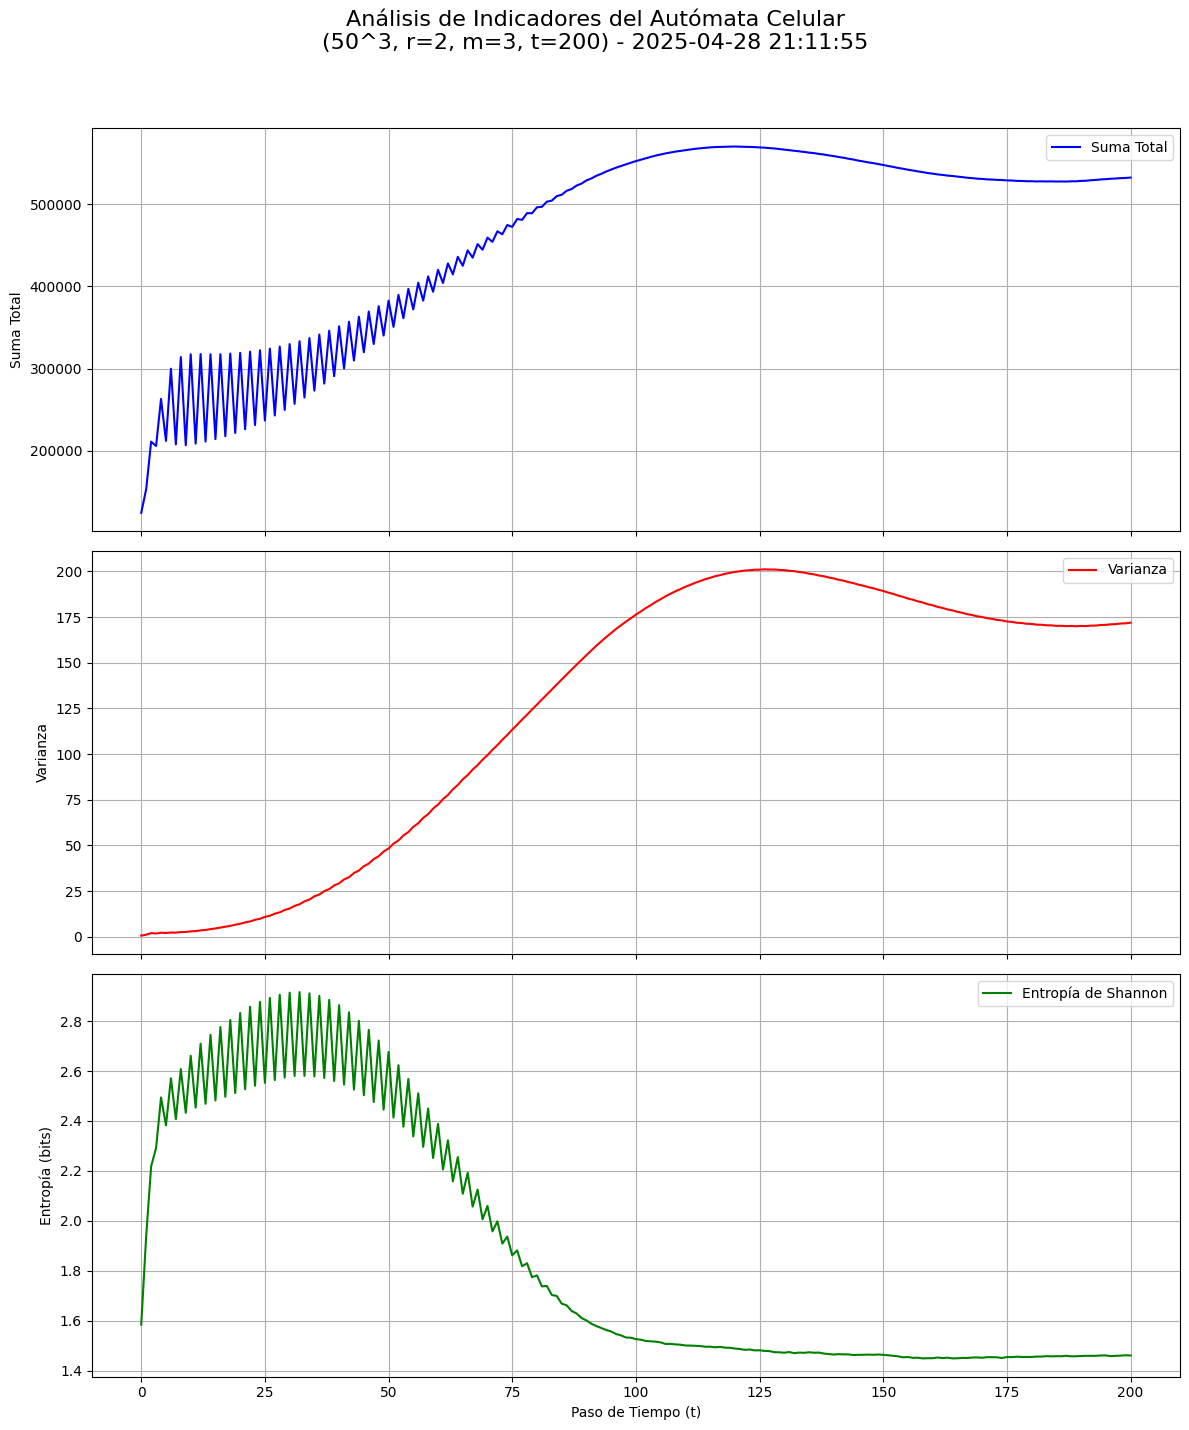

In [ ]:
# Crear figura con subplots para cada indicador
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True) # 3 filas, 1 columna

# Título general
fig.suptitle(f'Análisis de Indicadores del Autómata Celular\n({N_SIZE}^{D_DIM}, r={R_RADIUS}, m={M_STATES}, t={T_STEPS}) - {current_time_str}', fontsize=16)

# 1. Gráfico de Suma Total
axs[0].plot(total_sum_series, label='Suma Total', color='blue')
axs[0].set_ylabel('Suma Total')
axs[0].grid(True)
axs[0].legend()

# 2. Gráfico de Varianza
axs[1].plot(variance_series, label='Varianza', color='red')
axs[1].set_ylabel('Varianza')
axs[1].grid(True)
axs[1].legend()

# 3. Gráfico de Entropía
axs[2].plot(entropy_series, label='Entropía de Shannon', color='green')
axs[2].set_ylabel('Entropía (bits)')
axs[2].set_xlabel('Paso de Tiempo (t)')
axs[2].grid(True)
axs[2].legend()

# Ajustar espaciado y mostrar gráfico
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar para título general
plt.show()

##### Analisis busqueda de patrones
Se exploraron diferentes combinaciones de parámetros, encontrándose que la configuración con radio de vecindad $r=2$ y parámetro de umbral $m=3$ generaba las dinámicas más interesantes, caracterizadas por oscilaciones que visualmente se asemejan a la propagación de ondas a través de la grilla. Sin embargo, no se detectó periocidad evidente ni patrones semi-periódicos consitentes. Lo cual indica un comportamiento dinámico no cíclico bajos las condiciones en las cuales se experimentó.

### IMPLEMENTACION CON CUPY

#### Función `update_toroid_vectorized_cupy()`

In [ ]:
%%time
from cupyx.scipy.ndimage import convolve
def update_toroid_vectorized_cupy(grid, r, m, t):
    current_grid = grid.copy().astype(int)
    n = len(grid.shape)
    kernel = create_kernel(r, n)  # kernel de vecindad (radio r, dimensión n)

    num_neighbors = np.sum(kernel)

    Sm = m * num_neighbors

    interval_1 = Sm / 3
    interval_2 = 2 * Sm / 3

    for step in range(1, t + 1):
        sum_neighbors = convolve(current_grid, kernel, mode='wrap')

        new_grid = current_grid.copy()

        mask_decrease_1 = (sum_neighbors < interval_1)
        new_grid[mask_decrease_1] = current_grid[mask_decrease_1] - 1
        new_grid[mask_decrease_1 & (current_grid == 0)] = 0

        mask_increase = (sum_neighbors >= interval_1) & (sum_neighbors < interval_2)
        new_grid[mask_increase] = current_grid[mask_increase] + 1
        mask_decrease_2 = (sum_neighbors >= interval_2)

        new_grid[mask_decrease_2] = current_grid[mask_decrease_2] - 1
        new_grid[mask_decrease_2 & (current_grid == 0)] = 0

        current_grid = new_grid

    return new_grid

##### EXPERIMENTOS CON CUPY
Se utilizan las mismas métricas usadas para la comparación entre las implementaciones vectorizada y no vectorizada.

In [ ]:
grid01 = create_grid(n=15, d=3, m=3, aleatorio=True)

In [ ]:
%%time
result_vect_grid01 = update_toroid_vectorized_cupy(grid01, r=1, m=3, t=20)

CPU times: user 34.1 ms, sys: 0 ns, total: 34.1 ms
Wall time: 34.1 ms


---

In [ ]:
grid02 = create_grid(n=20, d=3, m=4, aleatorio=True)

In [ ]:
%%time
result_cycles_grid02 = update_toroid_vectorized_cupy(grid02, r=2, m=4, t=20)

CPU times: user 35 ms, sys: 0 ns, total: 35 ms
Wall time: 34.7 ms


---

In [ ]:
grid03 = create_grid(n=30, d=3, m=6, aleatorio=True)

In [ ]:
%%time
result_vect_grid03 = update_toroid_vectorized_cupy(grid03, r=2, m=6, t=20)

CPU times: user 35.1 ms, sys: 0 ns, total: 35.1 ms
Wall time: 35 ms


---

In [ ]:
grid04 = create_grid(n=40, d=3, m=3, aleatorio=True)

In [ ]:
%%time
result_vect_grid04 = update_toroid_vectorized_cupy(grid04, r=1, m=3, t=20)

CPU times: user 36.6 ms, sys: 3 µs, total: 36.6 ms
Wall time: 36.3 ms


---

In [ ]:
grid05 = create_grid(n=17, d=4, m=6, aleatorio=True)

In [ ]:
%%time
result_vect_grid05 = update_toroid_vectorized_cupy(grid05, r=2, m=6, t=20)

CPU times: user 77 ms, sys: 0 ns, total: 77 ms
Wall time: 81.1 ms


---

In [ ]:
grid06 = create_grid(n=20, d=4, m=4, aleatorio=True)

In [ ]:
%%time
result_vect_grid06 = update_toroid_vectorized_cupy(grid06, r=2, m=4, t=20)

CPU times: user 101 ms, sys: 0 ns, total: 101 ms
Wall time: 101 ms


---

In [ ]:
grid07 = create_grid(n=25, d=4, m=6, aleatorio=True)

In [ ]:
%%time
result_vect_grid07 = update_toroid_vectorized_cupy(grid07, r=2, m=3, t=20)

CPU times: user 159 ms, sys: 0 ns, total: 159 ms
Wall time: 159 ms


---

In [ ]:
grid08 = create_grid(n=15, d=5, m=6, aleatorio=True)

In [ ]:
%%time
result_vect_grid08 = update_toroid_vectorized_cupy(grid08, r=1, m=6, t=20)

CPU times: user 154 ms, sys: 32 µs, total: 154 ms
Wall time: 153 ms


---

In [ ]:
grid09 = create_grid(n=18, d=5, m=3, aleatorio=True)

In [ ]:
%%time
result_vect_grid09 = update_toroid_vectorized_cupy(grid09, r=2, m=3, t=20)

CPU times: user 1.47 s, sys: 0 ns, total: 1.47 s
Wall time: 1.47 s


---

In [ ]:
grid10 = create_grid(n=20, d=5, m=6, aleatorio=True)

In [ ]:
%%time
result_vect_grid10 = update_toroid_vectorized_cupy(grid10, r=1, m=6, t=20)

CPU times: user 409 ms, sys: 426 µs, total: 410 ms
Wall time: 409 ms


##### Tabla comparativa
Resultado de las tres implementaciones (tiempo en milisegundos). En la siguiente tabla se puede comparar que al utilizar `CuPy` se mejora aún más la rapidez en tareas de cálculo intesivo.


| d | m | r | n | no vectorizado | vectorizado | cupy | cantidad de celdas |
|---|----|----|----|-----------------|-------------|------|---------------------|
| 3  |  3  |  1  |  15  |   74.1              |    9.05         |   34.1   |  3375                   |
| 3  |  4  |  2  |  20  |    187.0             |    18.7         |   34.7   | 8000                    |
| 3  |  6  |  2  |  30  |     638.0            |    57.6         |   35   | 27000                    |
| 3  |  3  |  1  |  40  |     2100.0            |    109.0         |   36.3   | 64000                    |
| 4  |  6  |  1  |  17  |    2260.0             |    319.0         |  81.1    | 83521                    |
| 4  |  4  |  2  |  20  |    4390.0             |     517.0        |  101    | 160000                    |
| 4  |  6  |  2  |  25  |   11800.0              |     1360.0        |   159   | 390000                    |
| 5  |  6  |  1  |  15  |    21400.0             |    1190.0         |   153   | 759375                    |
| 5  |  3  |  2  |  18  |    68000.0             |     17900.0        |   1470   | 1889568                    |
| 5  |  6  |  1  |  20  |    88000.0             |     5390.0        |  409    | 3200000                    |

## CONCLUSIONES

Este trabajo logró demostrar en la práctica las ventajas de rendimiento de la programación vectorizada en `Python` para tareas de cálculo numérico intensas, como las simulaciones basadas en grillas. Si bien ambos métodos, el vectorizado y el basado en ciclos, implementan la misma lógica y utilizan la operación de convolución para el cálculo de la suma de vecinos, se distinguen en cómo aplican las reglas de actualización a cada celda.

La comparación directa confirma que el enfoque vectorizado es considerablemente más rápido y aún más la utilización de `CuPy`. Esta ganancia en velocidad se debe a que las operaciones vectorizadas de `Numpy` y `Scipy` delegan los ciclos y las operaciones elemento a elemento a código compilado y optimizado de bajo nivel, minimizando la sobrecarga asociada con la interpretación de ciclos y operaciones individuales en `Python` como en el método basado en ciclos. Por lo tanto, para problemas que involucran operaciones en grandes arreglos de datos, el estilo de programación vectorizado logra un rendimiento computacional superior.

Sin embargo, con relación a la búsqueda de patrones (teóricamente el sistema debería poseer patrones) al cuantificar las dinámicas para detectar periodicidad y a pesar de la aplicación de métricas globales y de complejidad, incluyendo la suma total de los valores de las celdas, la actividad dinámica (por ejemplo, el número de celdas que cambian de estado por paso de tiempo) y la entropía  (como medida de la complejidad o desorden del patrón en la grilla), solo se observaron oscilaciones persistentes tipo onda. Ninguna de las métricas aplicadas reveló una periodicidad clara y simple dentro del horizonte temporal de las simulaciones realizadas.

## REFERENCIAS
- Ceccherini-Silberstein, T. & Coornaert, M. (2023). Exercises in Cellular Automata and Groups. Springer.
- Hawkins, J. (2024). The Mathematics of Cellular Automata. American Mathematical Society.
- [Juego de la vida](https://es.wikipedia.org/wiki/Juego_de_la_vida)
- [Convolución `SciPy`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.convolve.html)
- [Convolución `CuPy`](https://docs.cupy.dev/en/stable/reference/generated/cupyx.scipy.ndimage.convolve.html)
